
# Interpretable Machine Learning (IML) Tutorial

This tutorial introduces Interpretable Machine Learning (IML) to help learners understand how and why models make predictions. By the end, participants will appreciate the importance of transparency, trust, and responsible AI, especially in high-stakes domains.


## Overview

In this tutorial we apply several **Interpretable Machine Learning (IML)** techniques to the Wisconsin Breast Cancer dataset. We compare:

| Technique | Scope | Model-agnostic? |
|---|---|---|
| Decision Tree feature importance | Global | No (tree-specific) |
| Random Forest feature importance | Global | No (tree-specific) |
| Permutation Importance | Global | Yes |
| SHAP | Global + Local | Yes (TreeExplainer for trees, KernelExplainer for others) |
| LIME | Local | Yes |

**Why does interpretability matter here?** Cancer diagnosis is high-stakes. A clinician needs to know *why* a model predicts malignant or benign not just that it does in order to trust, audit, and safely act on its output.

---


In [ ]:
# Import necessary libraries for data manipulation, plotting, and machine learning.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import modules from scikit-learn for dataset loading, model selection, and specific models.
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Import SHAP for explainable AI.
import shap

# Install LIME if it's not already installed. LIME is another explainable AI library.
try:
    from lime.lime_tabular import LimeTabularExplainer
except ModuleNotFoundError:
    !pip install lime
    from lime.lime_tabular import LimeTabularExplainer

# Set the default figure size for matplotlib plots.
plt.rcParams["figure.figsize"] = (8,6)


## Load Dataset

### About the dataset

`sklearn.datasets.load_breast_cancer` loads the **Wisconsin Breast Cancer** dataset (569 samples, 30 numeric features). Each sample is a digitised image of a fine needle aspirate (FNA) of a breast mass. Features describe properties of the cell nuclei such as radius, texture, perimeter, and concavity.

- **Target 0** → malignant  
- **Target 1** → benign

We load it into a Pandas DataFrame so that feature names are preserved throughout the analysis.


In [ ]:
# Load the breast cancer dataset from scikit-learn.
data = load_breast_cancer()

# Create a Pandas DataFrame from the feature data, using feature names from the dataset.
X = pd.DataFrame(data.data, columns=data.feature_names)

# Assign the target variable (malignant/benign) to 'y'.
y = data.target


In [ ]:
# Print the shape of the feature matrix (number of samples, number of features).
print(f"Dataset shape: {X.shape}")

# Print the target class meanings for clarity.
print("Target classes: 0 = malignant, 1 = benign\n")


Dataset shape: (569, 30)
Target classes: 0 = malignant, 1 = benign



In [ ]:
# Display the first 5 rows of the feature DataFrame to inspect the data.
X.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
# Display the column names (feature names) of the DataFrame.
X.columns


Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='object')

In [ ]:
# Display the target variable array to see its values.
y


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

## Train Test Split

### Why split the data?

We hold out 20 % of samples as a **test set** (`test_size=0.2`) so that all accuracy scores and importance estimates are measured on data the model has *never seen*. Setting `random_state=42` makes the split reproducible. Training on the remaining 80 % gives the models enough examples to learn meaningful patterns from all 30 features.


In [ ]:
# Split the dataset into training and testing sets.
# X: features, y: target variable
# test_size=0.2: 20% of the data will be used for testing.
# random_state=42: ensures reproducibility of the split.
# X.values is used to ensure X_train and X_test are NumPy arrays from the start,
# preventing UserWarnings about feature names when models are called by LIME.
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.2, random_state=42
)


## Model Building

### Interpretable Model

#### Decision Tree

### Decision Tree — an intrinsically interpretable model

A **Decision Tree** partitions the feature space using a sequence of axis-aligned thresholds (splits). At each internal node the tree asks a yes/no question about one feature (e.g., *"Is worst radius ≤ 16.8?"*). Samples flow left or right until they reach a leaf, which yields the predicted class.

**Why is it interpretable?**  
The full tree can be visualised and each prediction traced along a single root-to-leaf path. No post-hoc explanation technique is needed — the model *is* its own explanation.

**Trade-off:** A single unconstrained tree tends to overfit. We will compare its accuracy and feature rankings with the more powerful (but less transparent) Random Forest.


In [ ]:
# Initialize a Decision Tree Classifier with a fixed random state for reproducibility.
dt = DecisionTreeClassifier(random_state=42)

# Train the Decision Tree model on the training data.
dt.fit(X_train, y_train)

# Evaluate the model's accuracy on the test set and print it.
print("Accuracy:", dt.score(X_test, y_test))


Accuracy: 0.9473684210526315


#### Feature Importance

#### How Decision Tree feature importance is computed

`dt.feature_importances_` reports **Gini importance** (also called *mean decrease in impurity*). For each feature, sklearn accumulates the weighted reduction in Gini impurity across every node in the tree that splits on that feature. The values are then normalised so they sum to 1.

**Interpretation:** A higher bar means the feature was responsible for larger purity gains across the tree, it was used earlier and/or more frequently to separate the classes.

**Caveat:** Gini importance can overestimate continuous or high-cardinality features because they offer more possible split points. Permutation importance (introduced later) does not share this bias.


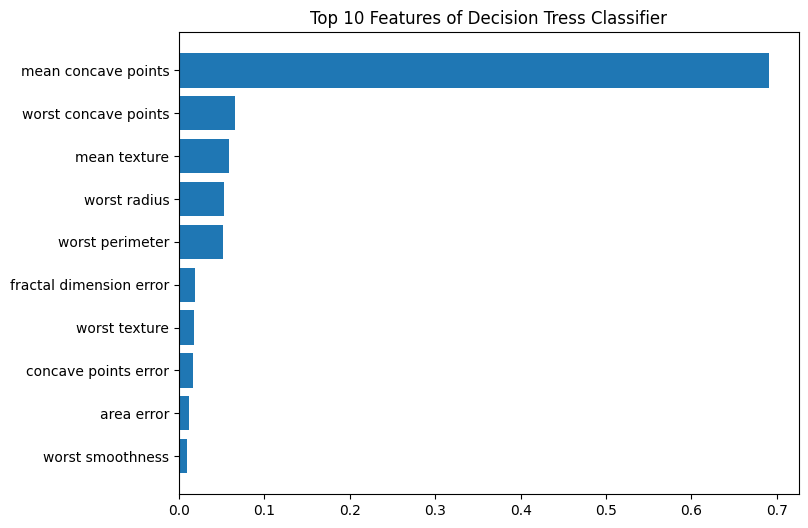

In [ ]:
# Get feature importances from the trained Decision Tree model.
importances = dt.feature_importances_

# Sort the feature importances in ascending order and get the indices of the top 10 features.
indices = np.argsort(importances)[-10:]

# Create a horizontal bar plot for the top 10 feature importances.
plt.barh(range(len(indices)), importances[indices])

# Set the y-axis ticks to the names of the top 10 features.
plt.yticks(range(len(indices)), X.columns[indices])

# Set the title of the plot.
plt.title("Top 10 Features of Decision Tress Classifier")

# Display the plot.
plt.show()


### Complex Model

####Random Forest

### Random Forest — a powerful but less transparent ensemble

A **Random Forest** trains many decision trees on bootstrap samples of the data, with each tree seeing a random subset of features at every split (*feature bagging*). The final prediction is the majority vote across all trees.

**Why is it harder to interpret?**  
There is no single tree to follow; predictions emerge from hundreds of overlapping trees. This is why we need dedicated explanation tools (permutation importance, SHAP, LIME) to understand what the ensemble has learned.

**Accuracy vs. interpretability:** The Random Forest typically outperforms a single Decision Tree by reducing variance through averaging. The accuracy difference below quantifies this trade-off.


In [ ]:
# Initialize a Random Forest Classifier with a fixed random state for reproducibility.
rf= RandomForestClassifier(random_state=42)

# Train the Random Forest model on the training data.
rf.fit(X_train, y_train)

# Evaluate the model's accuracy on the test set and print it.
print("Accuracy:", rf.score(X_test, y_test))


Accuracy: 0.9649122807017544


Feature Importance

#### Random Forest feature importance

`rf.feature_importances_` averages the Gini importance of each feature across **all trees** in the forest. Averaging reduces the noise present in any single tree and produces a more stable ranking.

Compare this plot with the Decision Tree importances above. Features that rank highly in *both* are likely to be genuinely important. Features that appear only in one may reflect noise or the idiosyncrasies of a particular tree.


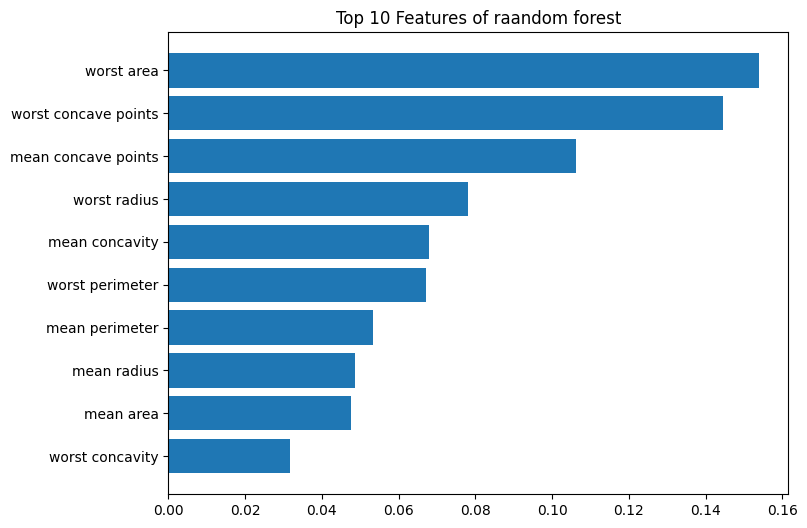

In [ ]:
# Get feature importances from the trained Random Forest model.
importances = rf.feature_importances_

# Sort the feature importances in ascending order and get the indices of the top 10 features.
indices = np.argsort(importances)[-10:]

# Create a horizontal bar plot for the top 10 feature importances.
plt.barh(range(len(indices)), importances[indices])

# Set the y-axis ticks to the names of the top 10 features.
plt.yticks(range(len(indices)), X.columns[indices])

# Set the title of the plot.
plt.title("Top 10 Features of raandom forest")

# Display the plot.
plt.show()



### Exercise 1
- For both the Decision Tree and Random Forest models, which feature appears most important?
- Why do you think these features influence predictions in each model?

### Permutation Importance for Random Forest



### Permutation Importance — a model-agnostic global method

**Core idea:** After training, take the test set and randomly shuffle the values of one feature column. Measure how much the model's accuracy drops. If accuracy falls a lot, that feature was important; if it barely changes, the model did not rely on it.

This is repeated `n_repeats=10` times per feature (with different random shuffles) to get a distribution of importance scores, shown here as a **box plot**. The width of each box reflects how stable the importance estimate is across shuffles.

**Advantages over Gini importance:**
- Works with *any* model (model-agnostic)
- Measured on held-out test data, so it reflects generalisation, not just training fit
- Not biased towards high-cardinality features

**Reading the plot:** Features on the right caused the largest drops in accuracy when shuffled, they are the ones the model relies on most.


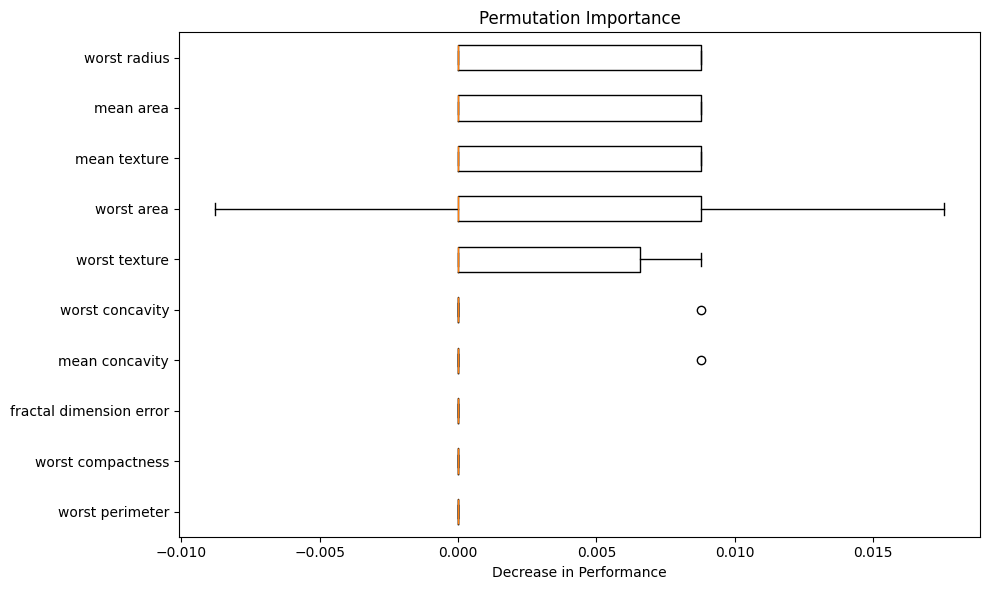

In [ ]:
# Import permutation_importance for calculating feature importance.
from sklearn.inspection import permutation_importance

# Calculate permutation importance for the Random Forest model.
# rf: the trained Random Forest model
# X_test, y_test: test data
# n_repeats=10: repeat the permutation 10 times for each feature
# random_state=42: ensures reproducibility
perm = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

# Get the indices of features sorted by their mean importance (top 10).
sorted_idx = perm.importances_mean.argsort()[-10:]

# Create a new figure for the plot.
plt.figure(figsize=(10, 6))

# Create a box plot of the permutation importances.
# perm.importances[sorted_idx].T: transpose the importances for plotting
# vert=False: horizontal box plots
# tick_labels: labels for the y-axis (feature names)
plt.boxplot(
    perm.importances[sorted_idx].T,
    vert=False,
    tick_labels=X.columns[sorted_idx]
)

# Set the title and x-axis label of the plot.
plt.title("Permutation Importance")
plt.xlabel("Decrease in Performance")

# Adjust layout to prevent labels from overlapping.
plt.tight_layout()

# Display the plot.
plt.show()


### Exercise 2
- Which features consistently have high permutation importance values across multiple repetitions?
- How does this compare to the feature importance from the Random Forest model?

### LIME Explanation for Random Forest

### LIME — Local Interpretable Model-agnostic Explanations

Where SHAP explains a model globally and locally using Shapley values, **LIME** focuses purely on *one prediction at a time*.

**How it works:**
1. Take the instance to be explained (`X_test.iloc[0]`).
2. Generate many perturbed versions of that instance by randomly masking or replacing feature values.
3. Ask the black-box model (`rf.predict_proba`) to score each perturbed sample.
4. Fit a simple **linear model** to those scores, weighted so that samples closer to the original instance count more.
5. The linear model's coefficients are the explanation they show which features pushed the prediction up or down *for this specific instance*.

**Key difference from SHAP:** LIME explanations are *local approximations* and can vary if you rerun them (due to the random perturbation step). SHAP values, by contrast, have a unique mathematical solution. Use LIME when you need a quick, human-readable explanation for a single case; use SHAP when consistency and global coherence matter.


In [ ]:
# Initialize a LimeTabularExplainer.
# training_data: the training features (as a numpy array).
# feature_names: names of the features (from the original DataFrame X).
# class_names: names of the target classes (e.g., 'malignant', 'benign').
# mode='classification': indicates a classification problem.
lime_explainer = LimeTabularExplainer(
    training_data=X_train, # X_train is now a NumPy array
    feature_names=X.columns, # Retain feature names from original X DataFrame
    class_names=data.target_names,
    mode='classification'
)

# Explain a specific instance from the test set (the first instance, index 0).
# X_test[0]: the feature values of the instance to explain (X_test is now a NumPy array).
# rf.predict_proba: the prediction probability function of the Random Forest model.
# num_features=10: display explanations for the top 10 most important features.
exp = lime_explainer.explain_instance(
    X_test[0], # Access the first row of the NumPy array X_test
    rf.predict_proba,
    num_features=10
)

# Display the LIME explanation in the notebook.
exp.show_in_notebook()


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


### SHAP Explanations for Random Forest

### SHAP — SHapley Additive exPlanations

SHAP originates from **cooperative game theory**. Each feature is treated as a "player" and its Shapley value measures its *average marginal contribution* to the prediction across all possible orderings of features.

For **tree-based models**, `shap.TreeExplainer` computes exact Shapley values in polynomial time by exploiting the tree structure, far faster than the model-agnostic KernelExplainer used later for the neural network.

**Summary plot interpretation:**
- Each row is one feature; each dot is one test sample.
- **Position on the x-axis** (SHAP value): positive → pushes the prediction toward *benign*; negative → pushes toward *malignant*.
- **Color**: red = high feature value, blue = low feature value.
- Patterns like "red dots on the right" for a feature mean *high values of that feature increase the benign probability*.

SHAP provides both **global** insight (overall feature ranking by mean |SHAP|) and **local** insight (exact contribution for each individual prediction).


In [ ]:
X_test.iloc[0]

,204
mean radius,12.470000
mean texture,18.600000
mean perimeter,81.090000
mean area,481.900000
mean smoothness,0.099650
mean compactness,0.105800
mean concavity,0.080050
mean concave points,0.038210
mean symmetry,0.192500
mean fractal dimension,0.063730


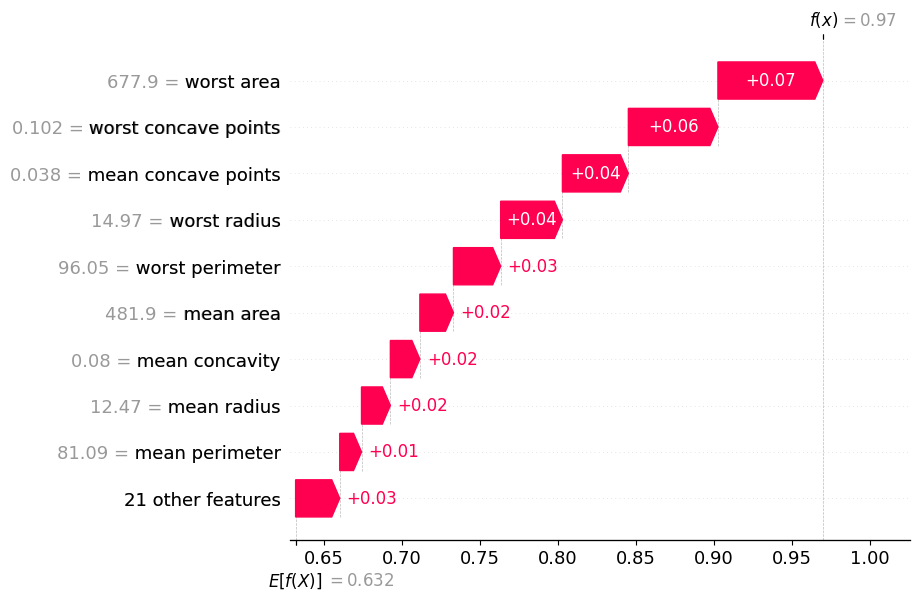

In [ ]:
shap.plots.waterfall(shap.Explanation(values=shap_values[0, :, 1], base_values=explainer.expected_value[1], data=X_test.iloc[0], feature_names=X.columns))

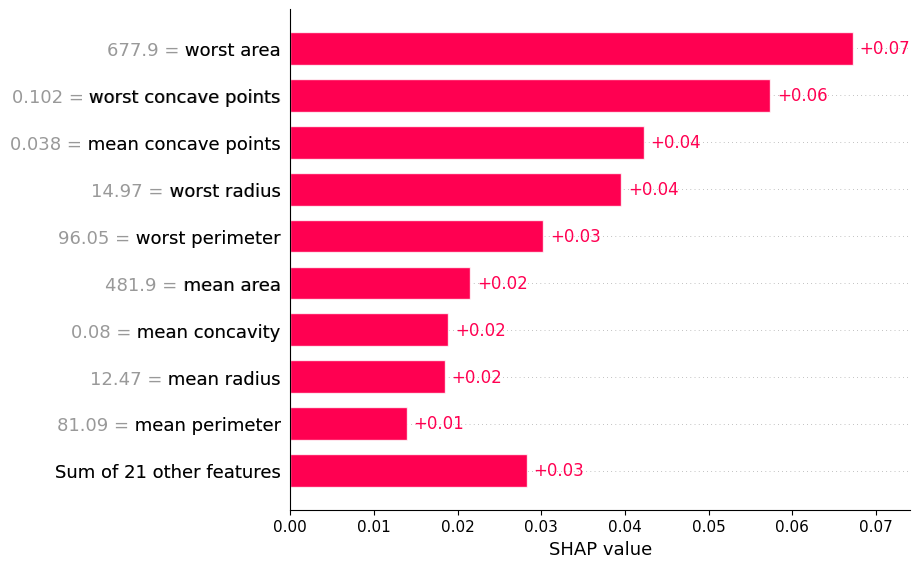

In [ ]:
shap.plots.bar(shap.Explanation(values=shap_values[0, :, 1], base_values=explainer.expected_value[1], data=X_test.iloc[0], feature_names=X.columns))

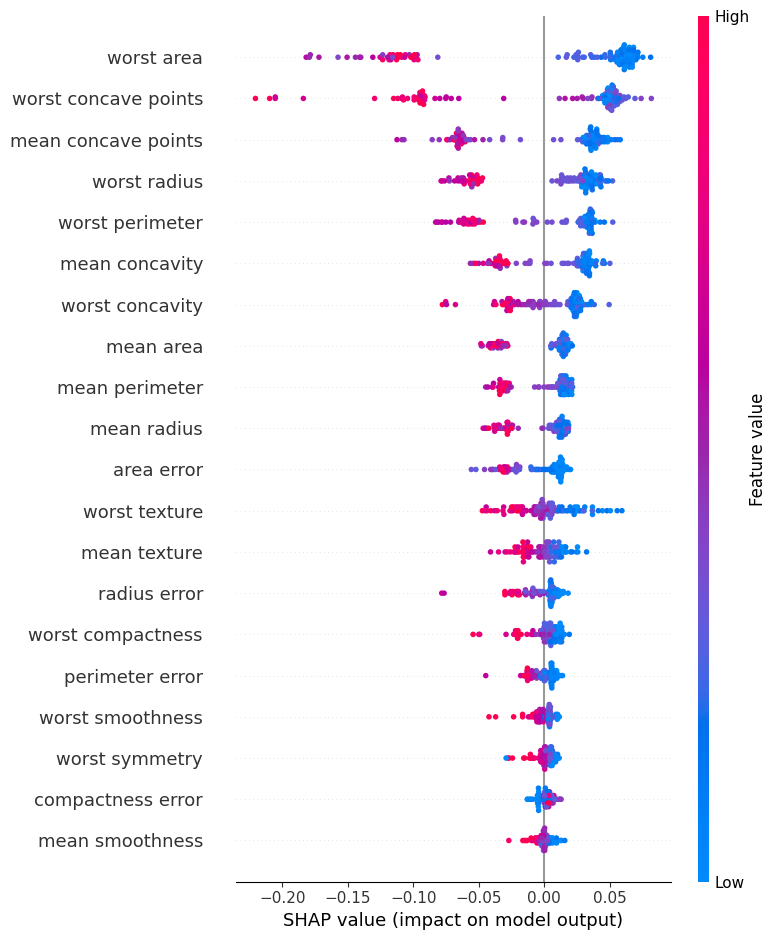

In [ ]:
# Initialize a SHAP TreeExplainer for the Random Forest model.
explainer = shap.TreeExplainer(rf)

# Calculate SHAP values for the test set. (shap_values is an array with explanations for each class)
shap_values = explainer.shap_values(X_test)

# Corrected: Select SHAP values for the second class (class index 1, representing 'benign') across all samples
# and generate a summary plot.
shap.summary_plot(shap_values[:, :, 1], X_test)


### Exercise 3
- What do the red and blue colors represent?
- Which features push predictions higher?



### Exercise 4
- Compare SHAP and LIME outputs.
- Do they highlight the same features?


### Simple Neural Network (MLPClassifier)

---
## Neural Network — extending IML to deep models

A **Multi-Layer Perceptron (MLPClassifier)** learns non-linear decision boundaries through layers of weighted connections and activation functions. It is a *black-box* model: its internal weights are not directly interpretable.

We now apply the same three post-hoc explanation techniques, permutation importance, SHAP, and LIME to the neural network and compare the results with those obtained for the Random Forest. This comparison illustrates that IML tools are **model-agnostic**: the same methods work regardless of the underlying model architecture.

`max_iter=1000` is set to ensure the optimiser converges on this dataset.


In [ ]:
# Import necessary modules for train-test split and the MLPClassifier.
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

# Ensure X_train, y_train, X_test, y_test are defined for this section by re-running the split.
# This is good practice to ensure consistent data splits if the notebook is run in parts.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize an MLPClassifier (Neural Network).
# random_state=42: for reproducibility.
# max_iter=1000: increased maximum number of iterations to help with convergence.
nn_model = MLPClassifier(random_state=42, max_iter=1000)

# Train the Neural Network model on the training data.
nn_model.fit(X_train, y_train)

# Evaluate the model's accuracy on the test set and print it.
print("Accuracy:", nn_model.score(X_test, y_test))


Accuracy: 0.9385964912280702


#### Permutation Importance for Neural Network

#### Permutation importance for the Neural Network

The procedure is identical to what we did for the Random Forest: shuffle each feature column on the test set and measure the accuracy drop. Because permutation importance only requires calling `model.score()`, it works with *any* sklearn-compatible estimator including neural networks.

Comparing this plot with the Random Forest permutation importance reveals whether the two models rely on the same features or have learned different representations of the data.


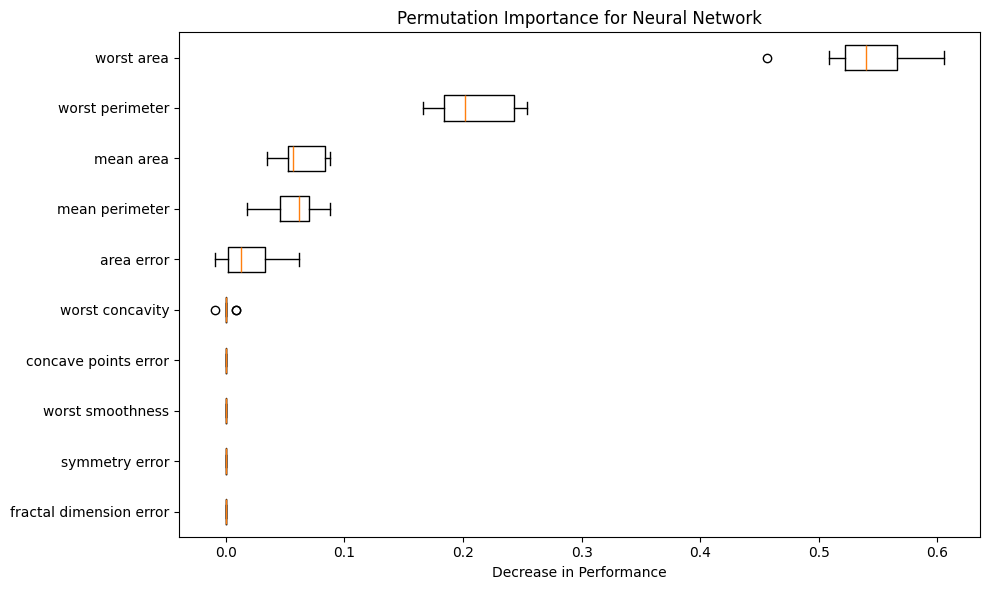

In [ ]:
# Import permutation_importance for calculating feature importance.
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import numpy as np

# Calculate permutation importance for the Neural Network model.
# nn_model: the trained Neural Network model.
# X_test, y_test: test data.
# n_repeats=10: repeat the permutation 10 times for each feature.
# random_state=42: ensures reproducibility.
perm_nn = permutation_importance(
    nn_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

# Get the indices of features sorted by their mean importance (top 10).
sorted_idx_nn = perm_nn.importances_mean.argsort()[-10:]

# Create a new figure for the plot.
plt.figure(figsize=(10, 6))

# Create a box plot of the permutation importances for the Neural Network.
# perm_nn.importances[sorted_idx_nn].T: transpose the importances for plotting.
# vert=False: horizontal box plots.
# tick_labels: labels for the y-axis (feature names).
plt.boxplot(
    perm_nn.importances[sorted_idx_nn].T,
    vert=False,
    tick_labels=X.columns[sorted_idx_nn]
)

# Set the title and x-axis label of the plot.
plt.title("Permutation Importance for Neural Network")
plt.xlabel("Decrease in Performance")

# Adjust layout to prevent labels from overlapping.
plt.tight_layout()

# Display the plot.
plt.show()


#### SHAP Explanations for Neural Network

#### SHAP for the Neural Network — KernelExplainer

`shap.TreeExplainer` only works with tree-based models. For the neural network we use **KernelExplainer**, the model-agnostic variant.

**How KernelExplainer works:**  
It estimates Shapley values by sampling coalitions of features, masking the others with values drawn from a *background dataset* (here `shap.sample(X_train, 100)`), and measuring the change in prediction. It then solves a weighted linear regression to find the Shapley values.

**Trade-off:** KernelExplainer is much slower than TreeExplainer because it cannot exploit model structure. We therefore explain only a 100-sample subset of the test set. In practice, this is a common compromise when applying SHAP to non-tree models.


  0%|          | 0/100 [00:00<?, ?it/s]

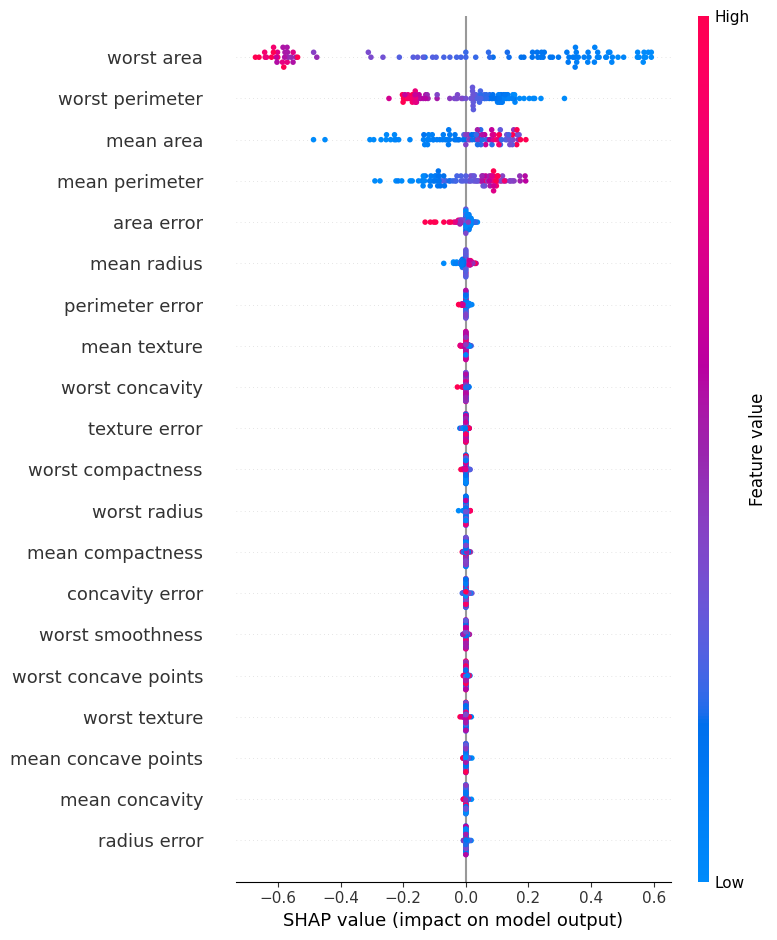

In [ ]:
# Import SHAP and pandas.
import shap
import pandas as pd

# Initialize a SHAP KernelExplainer for the Neural Network model.
# nn_model.predict_proba: the prediction probability function of the Neural Network.
# shap.sample(X_train, 100): use a sample of 100 training instances as the background dataset.
explainer_nn = shap.KernelExplainer(nn_model.predict_proba, shap.sample(X_train, 100))

# Calculate SHAP values for a sample of 100 instances from the test set.
# This is done because KernelExplainer can be computationally intensive.
shap_values_nn = explainer_nn.shap_values(shap.sample(X_test, 100))

# Corrected: Select SHAP values for the second class (class index 1) and generate a summary plot.
shap.summary_plot(shap_values_nn[:, :, 1], shap.sample(X_test, 100))


#### LIME Explanations for Neural Network

#### LIME for the Neural Network

We reuse the same `LimeTabularExplainer` setup, simply swapping `rf.predict_proba` for `nn_model.predict_proba`. This underlines a key property of LIME: the explainer is **completely decoupled from the model**. Only the prediction function matters.

Check whether the top features identified by LIME for the neural network match those found by SHAP and permutation importance. Systematic disagreement between methods can reveal model instability or features that are correlated (so that swapping one for another barely changes the output).


In [ ]:
# Import LimeTabularExplainer and pandas.
from lime.lime_tabular import LimeTabularExplainer
import pandas as pd

# Initialize a LimeTabularExplainer, similar to before.
# training_data: the training features (as a numpy array).
# feature_names: names of the features (from the original DataFrame X).
# class_names: names of the target classes.
# mode='classification': indicates a classification problem.
lime_explainer_nn = LimeTabularExplainer(
    training_data=X_train, # X_train is now a NumPy array
    feature_names=X.columns, # Retain feature names from original X DataFrame
    class_names=data.target_names,
    mode='classification'
)

# Explain a specific instance from the test set (the first instance, index 0) for the Neural Network.
# X_test[0]: the feature values of the instance to explain (X_test is now a NumPy array).
# nn_model.predict_proba: the prediction probability function of the Neural Network model.
# num_features=10: display explanations for the top 10 most important features.
exp_nn = lime_explainer_nn.explain_instance(
    X_test[0], # Access the first row of the NumPy array X_test
    nn_model.predict_proba,
    num_features=10
)

# Display the LIME explanation for the Neural Network in the notebook.
exp_nn.show_in_notebook()


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


### Exercise 5
- Compare the feature importance, permutation importance, SHAP, and LIME outputs for the Neural Network model.
- Are there any discrepancies between these methods, and if so, what might cause them?


## Quiz Questions

1. What is the difference between global and local interpretability?  
2. Which method (SHAP or LIME) provides global explanations?  
3. Why might two interpretability methods disagree?  
4. What is one limitation of feature importance?  
